#### NovaCred Data Quality Report

I. Uniqueness: Identified 2 duplicate _id groups (app_042, app_001) out of 502 records (~0.40%). Found 3 repeated non-null SSN values and 2 SSNs linked to multiple names (780-24-9300, 937-72-8731), indicating identity conflicts.

II. Consistency: financials.annual_income has mixed types (int: 488, str: 8, float: 6). Gender coding is inconsistent (Male, M, F, Female, empty). Format checks found 4 invalid emails and 157 DOB values not in standardized ISO format. Decision cross-field consistency checks all passed (0 violations).

III. Completeness: Key missingness includes notes (99.6%), financials.annual_salary (99.0%), loan_purpose (90.0%), processing_timestamp (87.6%), and decision fields tied to denied/approved outcomes (rejection_reason 58.2%, interest_rate 41.8%, approved_amount 41.8%). Critical applicant gaps: SSN 1.0%, IP 1.0%, annual_income 1.0%. All 5 missing annual_income cases were recoverable from annual_salary. Empty-value issues also present (e.g., email: 7 empty, DOB: 4 empty).

IV. Validity: Detected 2 negative credit_history_months, 1 negative savings_balance, and 1 zero annual_income. No extreme credit_history_months > 1200, no negative spending amounts, and no decision-rule validity violations.

V. Accuracy: DOB plausibility checks passed (<18: 0, >100: 0, future DOB: 0`) after mixed-format parsing logic.

#### Remediation Outcome:

i) Uniqueness remediation produced 501 rows; identity conflicts were retained and flagged (identity_conflict: 4 rows).

ii) Consistency remediation verification passed (income_numeric, gender_canonical, email_flag_ok, dob_iso all PASS).

iii) Completeness remediation reduced missing annual_income to 0 and missing gender to 0.

iv) Validity remediation reduced negative credit_history_months, negative savings_balance, and zero annual_income to 0.

In [1]:
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import hashlib

# Load and flatten nested JSON
try:
    with open('../data/raw_credit_applications.json', 'r') as f:
        df = pd.json_normalize(json.load(f))
    print(f"[SYSTEM] Ingested {len(df)} records.")
except Exception as e:
    print(f"[ERROR] Ingestion failed: {e}")

[SYSTEM] Ingested 502 records.


### Uniqueness Check

In [8]:
# -----------------------------
# I. UNIQUENESS
# -----------------------------
print("\n" + "="*70)
print("I. UNIQUENESS")
print("="*70)

# Existing: _id duplicates
id_counts = df["_id"].value_counts(dropna=False)
duplicate_ids = id_counts[id_counts > 1]
print(f"I.a Technical ID Duplicates (groups): {len(duplicate_ids)}")
print(f"I.a.1 Duplicate IDs: {duplicate_ids.index.tolist()}")

# Existing: SSN duplicates (total and non-null)
if "applicant_info.ssn" in df.columns:
    ssn_series = df["applicant_info.ssn"]

    non_null_ssn = ssn_series.dropna()
    ssn_counts = non_null_ssn.value_counts()
    repeated_ssns = ssn_counts[ssn_counts > 1]

    print(f"I.c Identity SSN Duplicates (Non-null repeated values): {int(repeated_ssns.sum()) - len(repeated_ssns) if len(repeated_ssns)>0 else 0}")
    print(f"I.c.1 Repeated SSN values: {repeated_ssns.index.tolist()}")

    # Existing deep-dive equivalent: possible identity conflict (same SSN, different names)
    if "applicant_info.full_name" in df.columns:
        ssn_name_conflicts = (
            df.dropna(subset=["applicant_info.ssn"])
              .groupby("applicant_info.ssn")["applicant_info.full_name"]
              .nunique()
        )
        conflict_ssns = ssn_name_conflicts[ssn_name_conflicts > 1]
        print(f"I.d SSN linked to multiple names: {len(conflict_ssns)}")
        if len(conflict_ssns) > 0:
            print(f"I.d.1 Conflict SSNs: {conflict_ssns.index.tolist()}")




I. UNIQUENESS
I.a Technical ID Duplicates (groups): 2
I.a.1 Duplicate IDs: ['app_042', 'app_001']
I.c Identity SSN Duplicates (Non-null repeated values): 3
I.c.1 Repeated SSN values: ['937-72-8731', '780-24-9300', '652-70-5530']
I.d SSN linked to multiple names: 2
I.d.1 Conflict SSNs: ['780-24-9300', '937-72-8731']


In [12]:
# I. UNIQUENESS - Deep dive into duplicate _id and duplicate SSN rows

print("\n" + "="*70)
print("I. UNIQUENESS - DEEP DIVE")
print("="*70)

# -----------------------------
# 1) Duplicate _id investigation
# -----------------------------
id_counts = df["_id"].value_counts(dropna=False)
dup_id_values = id_counts[id_counts > 1]

print(f"\nDuplicate _id groups: {len(dup_id_values)}")
print(f"Duplicate _id values: {dup_id_values.index.tolist()}")

dup_id_rows = (
    df[df["_id"].isin(dup_id_values.index)]
    .copy()
    .sort_values(["_id"])
)

# quick profile for duplicate-id rows
dup_id_rows["row_nulls"] = dup_id_rows.isna().sum(axis=1)
if "notes" not in dup_id_rows.columns:
    dup_id_rows["notes"] = np.nan

print("\nDuplicate _id rows (key fields):")
display(
    dup_id_rows[
        ["_id", "applicant_info.ssn", "applicant_info.full_name", "applicant_info.date_of_birth", "notes", "row_nulls"]
    ]
)

print("\nField-level differences within each duplicate _id group:")
for k, g in dup_id_rows.groupby("_id", dropna=False):
    varying_cols = [c for c in g.columns if g[c].astype(str).nunique(dropna=False) > 1]
    print(f"\n_id={k} | rows={len(g)} | varying_columns={len(varying_cols)}")
    if varying_cols:
        print(varying_cols[:20])  # first 20 for readability


# -----------------------------
# 2) Duplicate SSN investigation
# -----------------------
if "applicant_info.ssn" in df.columns:
    # Exclude null/empty SSN for identity analysis
    ssn_clean = (
        df["applicant_info.ssn"]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

    ssn_counts = ssn_clean.value_counts(dropna=True)
    dup_ssn_values = ssn_counts[ssn_counts > 1]

    print("\n" + "-"*70)
    print(f"Duplicate SSN values (non-empty): {len(dup_ssn_values)}")
    print(f"Duplicate SSN list: {dup_ssn_values.index.tolist()}")

    dup_ssn_rows = (
        df[ssn_clean.isin(dup_ssn_values.index)]
        .copy()
        .sort_values(["applicant_info.ssn", "_id"])
    )

    print("\nDuplicate SSN rows (key fields):")
    display(
        dup_ssn_rows[
            ["applicant_info.ssn", "_id", "applicant_info.full_name", "applicant_info.date_of_birth", "applicant_info.email"]
        ]
    )

    # Potential identity conflict: same SSN tied to multiple names or DOBs
    ssn_name_nunique = dup_ssn_rows.groupby("applicant_info.ssn")["applicant_info.full_name"].nunique(dropna=True)
    ssn_dob_nunique = dup_ssn_rows.groupby("applicant_info.ssn")["applicant_info.date_of_birth"].nunique(dropna=True)

    conflict_ssn = sorted(set(ssn_name_nunique[ssn_name_nunique > 1].index) |
                          set(ssn_dob_nunique[ssn_dob_nunique > 1].index))
else:
    print("Column applicant_info.ssn not found.")


I. UNIQUENESS - DEEP DIVE

Duplicate _id groups: 2
Duplicate _id values: ['app_042', 'app_001']

Duplicate _id rows (key fields):


,_id,applicant_info.ssn,applicant_info.full_name,applicant_info.date_of_birth,notes,row_nulls
383,app_001,427-90-1892,Stephanie Nguyen,1986-05-27,NaN,6
455,app_001,NaN,Stephanie Nguyen,NaN,DUPLICATE_ENTRY_ERROR,10
8,app_042,652-70-5530,Joseph Lopez,1990-05-04,NaN,6
354,app_042,652-70-5530,Joseph Lopez,1990-05-04,RESUBMISSION,5



Field-level differences within each duplicate _id group:

_id=app_001 | rows=2 | varying_columns=7
['applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'notes', 'row_nulls']

_id=app_042 | rows=2 | varying_columns=2
['notes', 'row_nulls']

----------------------------------------------------------------------
Duplicate SSN values (non-empty): 3
Duplicate SSN list: ['937-72-8731', '780-24-9300', '652-70-5530']

Duplicate SSN rows (key fields):


,applicant_info.ssn,_id,applicant_info.full_name,applicant_info.date_of_birth,applicant_info.email
8,652-70-5530,app_042,Joseph Lopez,1990-05-04,joseph.lopez1@gmail.com
354,652-70-5530,app_042,Joseph Lopez,1990-05-04,joseph.lopez1@gmail.com
122,780-24-9300,app_016,Gary Wilson,1959-12-11,gary.wilson85@yahoo.com
92,780-24-9300,app_088,Susan Martinez,1986-10-15,susan.martinez83@protonmail.com
16,937-72-8731,app_101,Sandra Smith,1997-03-23,sandra.smith99@icloud.com
499,937-72-8731,app_234,Samuel Hill,1976/01/29,samuel.hill67@protonmail.com


### Consistency Check

In [17]:
# -----------------------------
# II. CONSISTENCY
# -----------------------------
print("\n" + "="*70)
print("II. CONSISTENCY")
print("="*70)

# Existing: type consistency annual_income
if "financials.annual_income" in df.columns:
    print(f"II.a INCOME TYPES: {df['financials.annual_income'].apply(type).value_counts().to_dict()}")

# Existing: gender variations
if "applicant_info.gender" in df.columns:
    print(f"II.b GENDER VARIATIONS: {df['applicant_info.gender'].dropna().astype(str).unique().tolist()}")

# Missing: main field structure checks
def is_dict(x): return isinstance(x, dict)
def is_list(x): return isinstance(x, list)

if "_id" in df.columns:
    print(f"II.c _id not string: {(~df['_id'].apply(lambda x: isinstance(x, str))).sum()}")

for col, fn, label in [
    ("applicant_info", is_dict, "applicant_info not object"),
    ("financials", is_dict, "financials not object"),
    ("spending_behavior", is_list, "spending_behavior not array"),
    ("decision", is_dict, "decision not object"),
]:
    if col in df.columns:
        print(f"II.c {label}: {(~df[col].apply(fn)).sum()}")

# Missing: regex format checks
patterns = {
    "_id": r"^app_\d{3}(_r\d+)?$",
    "applicant_info.email": r"^[^@\s]+@[^@\s]+\.[^@\s]+$",
    "applicant_info.ssn": r"^\d{3}-\d{2}-\d{4}$",
    "applicant_info.zip_code": r"^\d{5}$",
    "applicant_info.ip_address": r"^(?:\d{1,3}\.){3}\d{1,3}$",
    "applicant_info.date_of_birth": r"^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12]\d|3[01])$" # YYYY-DD-MM
}

for col, pat in patterns.items():
    if col in df.columns:
        s = df[col].astype("string")
        non_empty = s.notna() & (s.str.strip() != "")
        bad = non_empty & ~s.str.match(pat, na=False)
        print(f"II.d format issues [{col}]: {int(bad.sum())}")

# Missing: decision.loan_approved allowed values
if "decision.loan_approved" in df.columns:
    bad_loan_approved = df["decision.loan_approved"].notna() & ~df["decision.loan_approved"].isin([True, False])
    print(f"II.e bad values [decision.loan_approved not boolean]: {int(bad_loan_approved.sum())}")


II. CONSISTENCY
II.a INCOME TYPES: {<class 'int'>: 488, <class 'str'>: 8, <class 'float'>: 6}
II.b GENDER VARIATIONS: ['Male', 'M', 'F', 'Female', '']
II.c _id not string: 0
II.c spending_behavior not array: 0
II.d format issues [_id]: 0
II.d format issues [applicant_info.email]: 4
II.d format issues [applicant_info.ssn]: 0
II.d format issues [applicant_info.zip_code]: 0
II.d format issues [applicant_info.ip_address]: 0
II.d format issues [applicant_info.date_of_birth]: 157
II.e bad values [decision.loan_approved not boolean]: 0


In [19]:
# Investigate a few email + DOB format issues (sample rows)

# Regex currently used in your consistency checks
email_pattern = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"
dob_pattern = r"^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12]\d|3[01])$" # YYYY-MM-DD

# Build masks
email_s = df["applicant_info.email"].astype("string")
dob_s = df["applicant_info.date_of_birth"].astype("string")

bad_email = email_s.notna() & (email_s.str.strip() != "") & ~email_s.str.match(email_pattern, na=False)
bad_dob = dob_s.notna() & (dob_s.str.strip() != "") & ~dob_s.str.match(dob_pattern, na=False)

print(f"Bad email rows: {int(bad_email.sum())}")
print(f"Bad DOB rows: {int(bad_dob.sum())}")

# Show a few rows for investigation
cols = [c for c in [
    "_id",
    "applicant_info.full_name",
    "applicant_info.email",
    "applicant_info.date_of_birth"
] if c in df.columns]

print("\nSample email format issues:")
display(df.loc[bad_email, cols].head(10))

print("\nSample DOB format issues:")
display(df.loc[bad_dob, cols].head(10))

Bad email rows: 4
Bad DOB rows: 157

Sample email format issues:


,_id,applicant_info.full_name,applicant_info.email,applicant_info.date_of_birth
138,app_204,Jonathan Carter,mike johnson@gmail.com,1983-04-12
181,app_299,Samuel Gonzalez,test.user.outlook.com,1972-08-28
276,app_068,Emily Lopez,john.doe@invalid,1993-09-05
369,app_146,Amy Flores,sarah.smith@,1970-04-26



Sample DOB format issues:


,_id,applicant_info.full_name,applicant_info.email,applicant_info.date_of_birth
5,app_275,Maria Miller,maria.miller67@outlook.com,14/02/1982
6,app_099,Nicholas King,nicholas.king46@outlook.com,28/01/1990
11,app_320,Jason Brown,jason.brown65@icloud.com,01/12/1978
14,app_307,Joseph Lee,joseph.lee69@aol.com,1990/07/26
21,app_173,Sarah Hall,sarah.hall95@hotmail.com,18/07/1979
23,app_289,Alexander Thompson,alexander.thompson21@mail.com,20/04/1979
32,app_274,Samantha Williams,samantha.williams57@icloud.com,1986/11/20
35,app_276,Sarah Harris,sarah.harris19@icloud.com,1995/05/07
36,app_386,Angela Carter,angela.carter72@gmail.com,03/20/1968
37,app_178,Brandon Harris,brandon.harris4@outlook.com,20/07/1997


In [26]:
# II. CONSISTENCY - Cross-Field Decision Consistency

print("\n" + "="*70)
print("II. CONSISTENCY - CROSS-FIELD DECISION CHECKS")
print("="*70)

required_cols = [
    "decision.loan_approved",
    "decision.interest_rate",
    "decision.approved_amount",
    "decision.rejection_reason"
]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print(f"Missing columns for this check: {missing_cols}")
else:
    approved = df["decision.loan_approved"].eq(True)
    denied = df["decision.loan_approved"].eq(False)

    ir = pd.to_numeric(df["decision.interest_rate"], errors="coerce")
    amt = pd.to_numeric(df["decision.approved_amount"], errors="coerce")
    rr = df["decision.rejection_reason"].astype("string").str.strip()

    # Rules
    approved_missing_or_invalid_ir = approved & (ir.isna() | (ir <= 0) | (ir > 100))
    approved_missing_or_nonpositive_amt = approved & (amt.isna() | (amt <= 0))
    approved_with_rejection_reason = approved & rr.notna() & (rr != "")

    denied_missing_rejection_reason = denied & (rr.isna() | (rr == ""))
    denied_with_interest_rate = denied & ir.notna()
    denied_with_positive_approved_amount = denied & amt.notna() & (amt > 0)

    print(f"approved_missing_or_invalid_interest_rate: {int(approved_missing_or_invalid_ir.sum())}")
    print(f"approved_missing_or_nonpositive_approved_amount: {int(approved_missing_or_nonpositive_amt.sum())}")
    print(f"approved_with_rejection_reason_present: {int(approved_with_rejection_reason.sum())}")
    print(f"denied_missing_rejection_reason: {int(denied_missing_rejection_reason.sum())}")
    print(f"denied_with_interest_rate_present: {int(denied_with_interest_rate.sum())}")
    print(f"denied_with_positive_approved_amount: {int(denied_with_positive_approved_amount.sum())}")

    # Show a few problematic rows
    issue_mask = (
        approved_missing_or_invalid_ir |
        approved_missing_or_nonpositive_amt |
        approved_with_rejection_reason |
        denied_missing_rejection_reason |
        denied_with_interest_rate |
        denied_with_positive_approved_amount
    )


II. CONSISTENCY - CROSS-FIELD DECISION CHECKS
approved_missing_or_invalid_interest_rate: 0
approved_missing_or_nonpositive_approved_amount: 0
approved_with_rejection_reason_present: 0
denied_missing_rejection_reason: 0
denied_with_interest_rate_present: 0
denied_with_positive_approved_amount: 0


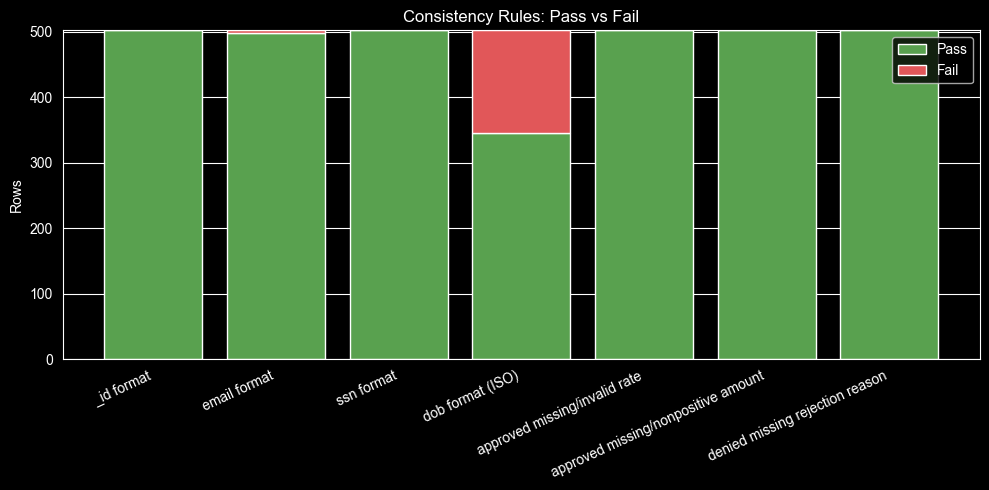

In [56]:
# CONSISTENCY
# Stacked pass/fail counts per rule
# -----------------------------
rule_results = {}

def non_empty(s):
    return s.notna() & (s.astype("string").str.strip() != "")

# Format rules
if "_id" in df.columns:
    s = df["_id"].astype("string")
    chk = non_empty(s)
    fail = chk & ~s.str.match(r"^app_\d{3}(_r\d+)?$", na=False)
    rule_results["_id format"] = int(fail.sum())

if "applicant_info.email" in df.columns:
    s = df["applicant_info.email"].astype("string")
    chk = non_empty(s)
    fail = chk & ~s.str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)
    rule_results["email format"] = int(fail.sum())

if "applicant_info.ssn" in df.columns:
    s = df["applicant_info.ssn"].astype("string")
    chk = non_empty(s)
    fail = chk & ~s.str.match(r"^\d{3}-\d{2}-\d{4}$", na=False)
    rule_results["ssn format"] = int(fail.sum())

if "applicant_info.date_of_birth" in df.columns:
    s = df["applicant_info.date_of_birth"].astype("string")
    chk = non_empty(s)
    # strict ISO for consistency section
    fail = chk & ~s.str.match(r"^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12]\d|3[01])$", na=False)
    rule_results["dob format (ISO)"] = int(fail.sum())

# Cross-field decision rules
needed = {"decision.loan_approved", "decision.interest_rate", "decision.approved_amount", "decision.rejection_reason"}
if needed.issubset(df.columns):
    approved = df["decision.loan_approved"].eq(True)
    denied = df["decision.loan_approved"].eq(False)
    ir = pd.to_numeric(df["decision.interest_rate"], errors="coerce")
    amt = pd.to_numeric(df["decision.approved_amount"], errors="coerce")
    rr = df["decision.rejection_reason"].astype("string").str.strip()

    rule_results["approved missing/invalid rate"] = int((approved & (ir.isna() | (ir <= 0) | (ir > 100))).sum())
    rule_results["approved missing/nonpositive amount"] = int((approved & (amt.isna() | (amt <= 0))).sum())
    rule_results["denied missing rejection reason"] = int((denied & (rr.isna() | (rr == ""))).sum())

cons_df = pd.DataFrame({
    "Rule": list(rule_results.keys()),
    "Fail": list(rule_results.values())
})
cons_df["Pass"] = len(df) - cons_df["Fail"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cons_df["Rule"], cons_df["Pass"], label="Pass", color="#59a14f")
ax.bar(cons_df["Rule"], cons_df["Fail"], bottom=cons_df["Pass"], label="Fail", color="#e15759")
ax.set_title("Consistency Rules: Pass vs Fail")
ax.set_ylabel("Rows")
ax.set_xlabel("")
ax.legend()
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Completeness Check

In [20]:
# -----------------------------
# III. COMPLETENESS
# -----------------------------
print("\n" + "="*70)
print("III. COMPLETENESS")
print("="*70)

# Existing: top missing fields report
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
missing_report = pd.DataFrame({"counts": null_counts, "pct": null_pct})
top_missing = missing_report[missing_report["counts"] > 0].sort_values(by="pct", ascending=False)

print("III.a Top Missing Fields")
for field, row in top_missing.iterrows():
    print(f"{field:35} | {int(row['counts']):3} missing | {row['pct']:5.1f}%")

# Existing deep dive: annual_income missing
if "financials.annual_income" in df.columns:
    missing_income = df["financials.annual_income"].isna().sum()
    print(f"\nIII.b Missing financials.annual_income: {int(missing_income)}")
    if "financials.annual_salary" in df.columns:
        salary_when_income_missing = df.loc[df["financials.annual_income"].isna(), "financials.annual_salary"].notna().sum()
        print(f"III.b.1 Cases where annual_salary exists while annual_income missing: {int(salary_when_income_missing)}")

# Missing: exists/empty checks for specific fields
applicant_fields = [
    "applicant_info.full_name", "applicant_info.email", "applicant_info.ssn",
    "applicant_info.ip_address", "applicant_info.gender",
    "applicant_info.date_of_birth", "applicant_info.zip_code"
]
financial_fields = [
    "financials.annual_income", "financials.credit_history_months",
    "financials.debt_to_income", "financials.savings_balance"
]

def empty_count(series):
    s = series.astype("string")
    return int(((s.str.strip() == "") & series.notna()).sum())

for f in applicant_fields + financial_fields:
    if f in df.columns:
        print(f"III.c {f:30} | missing: {int(df[f].isna().sum()):3} | empty: {empty_count(df[f]):3}")

# Missing: spending_behavior completeness
if "spending_behavior" in df.columns:
    empty_arrays = df["spending_behavior"].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
    missing_or_nonlist = (df["spending_behavior"].isna() | ~df["spending_behavior"].apply(lambda x: isinstance(x, list))).sum()
    print(f"III.d spending_behavior empty arrays: {int(empty_arrays)}")
    print(f"III.d.1 spending_behavior missing/non-list: {int(missing_or_nonlist)}")

    sb = df[["_id", "spending_behavior"]].explode("spending_behavior")
    sb = sb[sb["spending_behavior"].apply(lambda x: isinstance(x, dict))]
    cat_missing_empty = sb["spending_behavior"].apply(lambda d: ("category" not in d) or (d.get("category") in [None, ""])).sum()
    amt_missing_empty = sb["spending_behavior"].apply(lambda d: ("amount" not in d) or (d.get("amount") in [None, ""])).sum()
    print(f"III.d.2 spending_behavior.category missing/empty: {int(cat_missing_empty)}")
    print(f"III.d.3 spending_behavior.amount missing/empty: {int(amt_missing_empty)}")


# Observation:
# The 'missing' income data is actually present but under a different field name 'annual_salary'. This indicates a schema inconsistency where some records use 'annual_income' and others use 'annual_salary' for the same data point. This should be standardized in the cleaning process.


III. COMPLETENESS
III.a Top Missing Fields
notes                               | 500 missing |  99.6%
financials.annual_salary            | 497 missing |  99.0%
loan_purpose                        | 452 missing |  90.0%
processing_timestamp                | 440 missing |  87.6%
decision.rejection_reason           | 292 missing |  58.2%
decision.interest_rate              | 210 missing |  41.8%
decision.approved_amount            | 210 missing |  41.8%
applicant_info.ssn                  |   5 missing |   1.0%
applicant_info.ip_address           |   5 missing |   1.0%
financials.annual_income            |   5 missing |   1.0%
applicant_info.gender               |   1 missing |   0.2%
applicant_info.date_of_birth        |   1 missing |   0.2%
applicant_info.zip_code             |   1 missing |   0.2%

III.b Missing financials.annual_income: 5
III.b.1 Cases where annual_salary exists while annual_income missing: 5
III.c applicant_info.full_name       | missing:   0 | empty:   0
III.c app

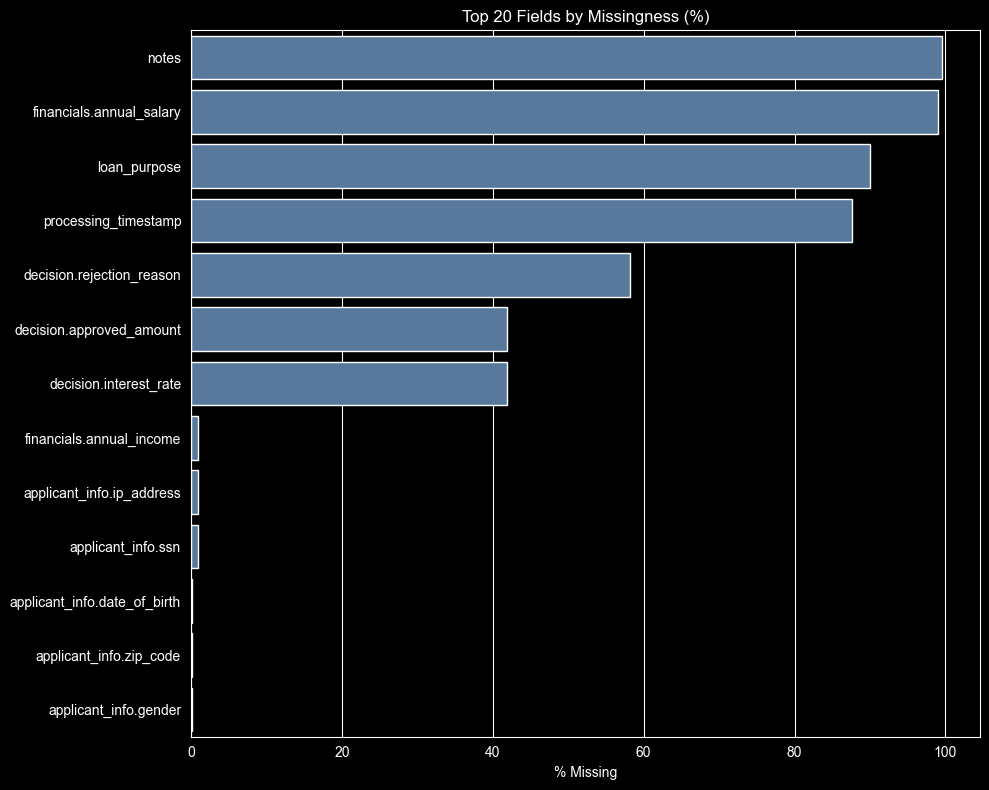

In [38]:
# III. COMPLETENESS
# Top missing fields (%)
# -----------------------------
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct[missing_pct > 0].head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_missing.values, y=top_missing.index, color="#4c78a8")
plt.title("Top 20 Fields by Missingness (%)")
plt.xlabel("% Missing")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Validity Check

In [6]:
# IV. VALIDITY
# -----------------------------
print("\n" + "="*70)
print("IV. VALIDITY")
print("="*70)

# Existing: negative history/savings
if "financials.credit_history_months" in df.columns:
    print(f"IV.a NEGATIVE credit_history_months: {int((pd.to_numeric(df['financials.credit_history_months'], errors='coerce') < 0).sum())}")
if "financials.savings_balance" in df.columns:
    print(f"IV.b NEGATIVE savings_balance: {int((pd.to_numeric(df['financials.savings_balance'], errors='coerce') < 0).sum())}")

# Existing: zero income logic check
if "financials.annual_income" in df.columns:
    income_num = pd.to_numeric(df["financials.annual_income"], errors="coerce")
    print(f"IV.c Zero annual_income applicants: {int((income_num == 0).sum())}")

# Existing: impossible history outlier
if "financials.credit_history_months" in df.columns:
    ch = pd.to_numeric(df["financials.credit_history_months"], errors="coerce")
    print(f"IV.d RANGE VIOLATIONS credit_history_months > 1200: {int((ch > 1200).sum())}")

# Missing: extra negative checks
for c in ["financials.annual_income", "financials.debt_to_income", "decision.interest_rate", "decision.approved_amount"]:
    if c in df.columns:
        vals = pd.to_numeric(df[c], errors="coerce")
        print(f"IV.e NEGATIVE [{c}]: {int((vals < 0).sum())}")

# Missing: spending amount negative
if "spending_behavior" in df.columns:
    sb = df[["_id", "spending_behavior"]].explode("spending_behavior")
    sb = sb[sb["spending_behavior"].apply(lambda x: isinstance(x, dict))]
    amt = pd.to_numeric(sb["spending_behavior"].apply(lambda d: d.get("amount")), errors="coerce")
    print(f"IV.f NEGATIVE [spending_behavior.amount]: {int((amt < 0).sum())}")

# Missing: decision logic checks
if {"decision.loan_approved", "decision.interest_rate"}.issubset(df.columns):
    print(f"IV.g approved_missing_interest_rate: {int(((df['decision.loan_approved'] == True) & df['decision.interest_rate'].isna()).sum())}")

if {"decision.loan_approved", "decision.approved_amount"}.issubset(df.columns):
    print(f"IV.h approved_missing_approved_amount: {int(((df['decision.loan_approved'] == True) & df['decision.approved_amount'].isna()).sum())}")

if {"decision.loan_approved", "decision.rejection_reason"}.issubset(df.columns):
    rr = df["decision.rejection_reason"].astype("string")
    print(f"IV.i denied_missing_rejection_reason: {int(((df['decision.loan_approved'] == False) & (rr.isna() | (rr.str.strip() == ''))).sum())}")


IV. VALIDITY
IV.a NEGATIVE credit_history_months: 2
IV.b NEGATIVE savings_balance: 1
IV.c Zero annual_income applicants: 1
IV.d RANGE VIOLATIONS credit_history_months > 1200: 0
IV.e NEGATIVE [financials.annual_income]: 0
IV.e NEGATIVE [financials.debt_to_income]: 0
IV.e NEGATIVE [decision.interest_rate]: 0
IV.e NEGATIVE [decision.approved_amount]: 0
IV.f NEGATIVE [spending_behavior.amount]: 0
IV.g approved_missing_interest_rate: 0
IV.h approved_missing_approved_amount: 0
IV.i denied_missing_rejection_reason: 0


In [23]:
### Validity Investigation

print("\n" + "="*70)
print("IV. VALIDITY - INVESTIGATION")
print("="*70)

# numeric-safe versions
ch = pd.to_numeric(df["financials.credit_history_months"], errors="coerce")
sb = pd.to_numeric(df["financials.savings_balance"], errors="coerce")
ai = pd.to_numeric(df["financials.annual_income"], errors="coerce")

neg_ch_mask = ch < 0
neg_sb_mask = sb < 0
zero_ai_mask = ai == 0

print(f"Negative credit_history_months rows: {int(neg_ch_mask.sum())}")
print(f"Negative savings_balance rows: {int(neg_sb_mask.sum())}")
print(f"Zero annual_income rows: {int(zero_ai_mask.sum())}")

# useful columns for investigation
cols = [c for c in [
    "_id",
    "applicant_info.full_name",
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.savings_balance",
    "decision.loan_approved",
    "decision.approved_amount",
    "decision.rejection_reason",
    "notes"
] if c in df.columns]

print("\nSample rows with negative credit_history_months:")
display(df.loc[neg_ch_mask, cols].head(10))

print("\nSample rows with negative savings_balance:")
display(df.loc[neg_sb_mask, cols].head(10))

print("\nSample rows with zero annual_income:")
display(df.loc[zero_ai_mask, cols].head(10))

# overlap diagnostics (same row failing multiple checks)
overlap = pd.DataFrame({
    "neg_credit_history": neg_ch_mask,
    "neg_savings_balance": neg_sb_mask,
    "zero_annual_income": zero_ai_mask
})


IV. VALIDITY - INVESTIGATION
Negative credit_history_months rows: 2
Negative savings_balance rows: 1
Zero annual_income rows: 1

Sample rows with negative credit_history_months:


,_id,applicant_info.full_name,financials.annual_income,financials.credit_history_months,financials.savings_balance,decision.loan_approved,decision.approved_amount,decision.rejection_reason,notes
137,app_043,Daniel King,131000,-10,53098,True,68000.0,NaN,NaN
162,app_156,Jessica Green,25000,-3,13641,False,NaN,algorithm_risk_score,NaN



Sample rows with negative savings_balance:


,_id,applicant_info.full_name,financials.annual_income,financials.credit_history_months,financials.savings_balance,decision.loan_approved,decision.approved_amount,decision.rejection_reason,notes
159,app_290,Stephanie Perez,104000,39,-5000,True,49000.0,NaN,NaN



Sample rows with zero annual_income:


,_id,applicant_info.full_name,financials.annual_income,financials.credit_history_months,financials.savings_balance,decision.loan_approved,decision.approved_amount,decision.rejection_reason,notes
426,app_190,Heather White,0,0,19603,False,NaN,algorithm_risk_score,NaN


### Accuracy Check

In [33]:
# V. ACCURACY
# -----------------------------
print("\n" + "="*70)
print("V. ACCURACY")
print("="*70)

if "applicant_info.date_of_birth" not in df.columns:
    print("Missing column: applicant_info.date_of_birth")
else:
    dob_raw = df["applicant_info.date_of_birth"].astype("string").str.strip()

    # Parse both ISO and non-ISO formats seen in dataset
    dob_iso = pd.to_datetime(dob_raw, format="%Y-%m-%d", errors="coerce")
    dob_dmy = pd.to_datetime(dob_raw, format="%d/%m/%Y", errors="coerce")
    dob_ymd_slash = pd.to_datetime(dob_raw, format="%Y/%m/%d", errors="coerce")

    dob = dob_iso.fillna(dob_dmy).fillna(dob_ymd_slash)
    dob = pd.Series(dob, index=df.index)

    # 1) Age plausibility
    today = pd.Timestamp.today().normalize()
    age_years = ((today - dob).dt.days / 365.25)

    age_under_18 = dob.notna() & (age_years < 18)
    age_over_100 = dob.notna() & (age_years > 100)
    dob_in_future = dob.notna() & (dob > today)

    print(f"V.a Age < 18: {int(age_under_18.sum())}")
    print(f"V.b Age > 100: {int(age_over_100.sum())}")
    print(f"V.c DOB in the future: {int(dob_in_future.sum())}")

    cols_age = [c for c in ["_id", "applicant_info.full_name", "applicant_info.date_of_birth"] if c in df.columns]



V. ACCURACY
V.a Age < 18: 0
V.b Age > 100: 0
V.c DOB in the future: 0


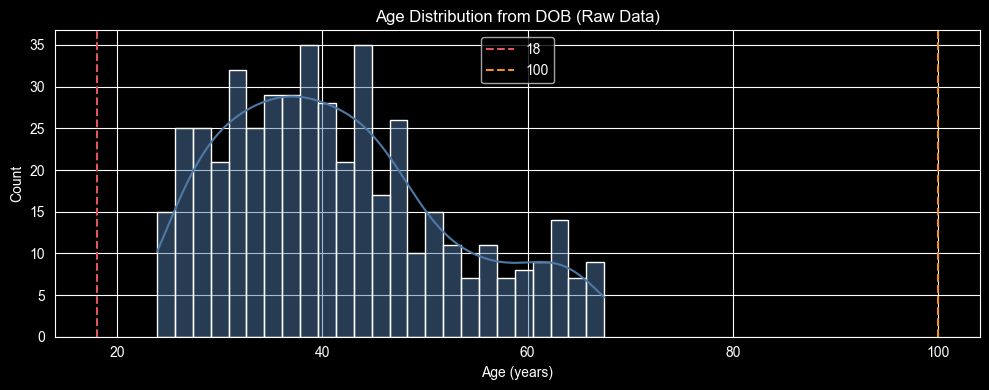

In [40]:
# V. ACCURACY
# Age histogram
# -----------------------------
if "applicant_info.date_of_birth" in df.columns:
    dob_raw = df["applicant_info.date_of_birth"].astype("string").str.strip()

    # Accept mixed formats for accuracy parsing
    dob = (
        pd.to_datetime(dob_raw, format="%Y-%m-%d", errors="coerce")
        .fillna(pd.to_datetime(dob_raw, format="%d/%m/%Y", errors="coerce"))
        .fillna(pd.to_datetime(dob_raw, format="%Y/%m/%d", errors="coerce"))
    )

    today = pd.Timestamp.today().normalize()
    age = ((today - dob).dt.days / 365.25)

    plt.figure(figsize=(10, 4))
    sns.histplot(age.dropna(), bins=25, kde=True, color="#4e79a7")
    plt.axvline(18, color="#e15759", linestyle="--", label="18")
    plt.axvline(100, color="#f28e2b", linestyle="--", label="100")
    plt.title("Age Distribution from DOB (Raw Data)")
    plt.xlabel("Age (years)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Remediation Steps

### Uniqueness

In [41]:
### Uniqueness

df_clean2 = df.copy()

## Fixing ID duplicates

# Normalize notes
notes = (
    df_clean2["notes"].astype("string").str.strip()
    if "notes" in df_clean2.columns
    else pd.Series(pd.NA, index=df_clean2.index, dtype="string")
)

# ------------------------------------------------------------
# Step 1: Handle RESUBMISSION
# If notes == RESUBMISSION, rename _id (app_042 -> app_042_r1)
# ------------------------------------------------------------
if "_id" in df_clean2.columns:
    resub_idx = df_clean2.index[notes.eq("RESUBMISSION")]

    for idx in resub_idx:
        base_id = str(df_clean2.at[idx, "_id"])
        n = 1
        new_id = f"{base_id}_r{n}"

        # ensure unique id
        while (df_clean2["_id"] == new_id).any():
            n += 1
            new_id = f"{base_id}_r{n}"

        df_clean2.at[idx, "_id"] = new_id

# ------------------------------------------------------------
# Step 2: Handle DUPLICATE_ENTRY_ERROR
# If notes == DUPLICATE_ENTRY_ERROR, drop row with more missing fields
# ------------------------------------------------------------
df_clean2["_missing_count"] = df_clean2.isna().sum(axis=1)
to_drop = []

if "_id" in df_clean2.columns:
    dup_ids = df_clean2.loc[df_clean2.duplicated("_id", keep=False), "_id"].unique()

    for gid in dup_ids:
        g = df_clean2[df_clean2["_id"] == gid].copy()
        g_notes = notes.loc[g.index]

        # apply rule only if this duplicate group has a DUPLICATE_ENTRY_ERROR row
        if not g_notes.eq("DUPLICATE_ENTRY_ERROR").any():
            continue

        min_missing = g["_missing_count"].min()
        best = g[g["_missing_count"] == min_missing]

        # tie-breaker: prefer non-DUPLICATE_ENTRY_ERROR row
        best_notes = notes.loc[best.index]
        non_err = best[~best_notes.eq("DUPLICATE_ENTRY_ERROR")]
        keep_idx = non_err.index[0] if len(non_err) > 0 else best.index[0]

        drop_idx = [i for i in g.index if i != keep_idx]
        to_drop.extend(drop_idx)

df_clean2 = df_clean2.drop(index=pd.Index(to_drop).unique())



# Fixing SSN conflicts
# ------------------------------------------------------------
# If same SSN but different name -> create identity_conflict flag = True (do not delete)
# ------------------------------------------------------------
df_clean2["identity_conflict"] = False

if {"applicant_info.ssn", "applicant_info.full_name"}.issubset(df_clean2.columns):
    ssn = (
        df_clean2["applicant_info.ssn"]
        .astype("string").str.strip().replace("", pd.NA)
    )
    name = (
        df_clean2["applicant_info.full_name"]
        .astype("string").str.strip().str.lower().replace("", pd.NA)
    )

    t = pd.DataFrame({"ssn": ssn, "name": name}, index=df_clean2.index).dropna(subset=["ssn"])
    conflict_ssn = t.groupby("ssn")["name"].nunique(dropna=True)
    conflict_ssn = conflict_ssn[conflict_ssn > 1].index

    conflict_idx = t[t["ssn"].isin(conflict_ssn)].index
    df_clean2.loc[conflict_idx, "identity_conflict"] = True

# Removing cleanup helper column - '_missing_count'
df_clean2 = df_clean2.drop(columns=["_missing_count"], errors="ignore")

print(f"Rows in cleaned copy: {len(df_clean2)}")
print(f"Identity conflict rows flagged: {int(df_clean2['identity_conflict'].sum())}")
display(df_clean2.head())

Rows in cleaned copy: 501
Identity conflict rows flagged: 4


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes,identity_conflict
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,False
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,False
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN,False
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN,False
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,False


### Consistency

In [44]:
# Solving the consistency problem
df_consistency = df_clean2.copy()

# -----------------------------
# 1) Income type consistency
# Converting all income type to float
# -----------------------------
if "financials.annual_income" in df_consistency.columns:
    df_consistency["financials.annual_income"] = pd.to_numeric(
        df_consistency["financials.annual_income"],
        errors="coerce"
    ).astype("float64")

# -----------------------------
# 2) Gender consistency
# Converting all inconsistent gender to a single format
# -----------------------------
if "applicant_info.gender" in df_consistency.columns:
    g = df_consistency["applicant_info.gender"].astype("string").str.strip()

    gender_map = {
        "Male": "Male",
        "M": "Male",
        "m": "Male",
        "Female": "Female",
        "F": "Female",
        "f": "Female",
        "": pd.NA
    }

    df_consistency["applicant_info.gender"] = g.replace(gender_map)

# -----------------------------
# 3) Email format flag
# Flagging bad email formats
# -----------------------------
if "applicant_info.email" in df_consistency.columns:
    email_pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"

    email_clean = (
        df_consistency["applicant_info.email"]
        .astype("string")
        .str.strip()
        .str.lower()
    )
    email_clean = email_clean.mask(email_clean == "", pd.NA)

    df_consistency["applicant_info.email"] = email_clean
    df_consistency["email_valid"] = email_clean.str.match(email_pattern, na=False)
    df_consistency.loc[email_clean.isna(), "email_valid"] = pd.NA

# -----------------------------
# 4) DOB standardization
# Standardizing the date of birth to ISO format
# -----------------------------
if "applicant_info.date_of_birth" in df_consistency.columns:
    dob_raw = df_consistency["applicant_info.date_of_birth"].astype("string").str.strip()

    dob_iso = pd.to_datetime(dob_raw, format="%Y-%m-%d", errors="coerce")
    dob_dmy = pd.to_datetime(dob_raw, format="%d/%m/%Y", errors="coerce")
    dob_mdy = pd.to_datetime(dob_raw, format="%m/%d/%Y", errors="coerce")
    dob_ymd_slash = pd.to_datetime(dob_raw, format="%Y/%m/%d", errors="coerce")

    dob_parsed = dob_iso.fillna(dob_dmy).fillna(dob_mdy).fillna(dob_ymd_slash)
    df_consistency["applicant_info.date_of_birth"] = dob_parsed.dt.strftime("%Y-%m-%d")


# -----------------------------
# Quick verification
# -----------------------------
print("Consistency remediation complete.")
checks = {}

# 1) annual_income numeric
if "financials.annual_income" in df_consistency.columns:
    x = pd.to_numeric(df_consistency["financials.annual_income"], errors="coerce")
    checks["income_numeric"] = x.notna().sum() == df_consistency["financials.annual_income"].notna().sum()

# 2) gender canonical
if "applicant_info.gender" in df_consistency.columns:
    g = df_consistency["applicant_info.gender"]
    checks["gender_canonical"] = ((g.isna()) | (g.isin(["Male", "Female"]))).all()

# 3) email flag present for non-empty emails
if {"applicant_info.email", "email_valid"}.issubset(df_consistency.columns):
    e = df_consistency["applicant_info.email"].astype("string").str.strip()
    checks["email_flag_ok"] = df_consistency.loc[e.notna() & (e != ""), "email_valid"].isin([True, False]).all()

# 4) DOB in YYYY-MM-DD
if "applicant_info.date_of_birth" in df_consistency.columns:
    d = df_consistency["applicant_info.date_of_birth"].astype("string").str.strip()
    checks["dob_iso"] = d.loc[d.notna() & (d != "")].str.match(r"^\d{4}-\d{2}-\d{2}$", na=False).all()

for k, v in checks.items():
    print(f"{k}: {'PASS' if v else 'FAIL'}")

Consistency remediation complete.
income_numeric: PASS
gender_canonical: PASS
email_flag_ok: PASS
dob_iso: PASS


### Completeness

In [47]:
# Completeness remediation

df_completeness = df_consistency.copy()

# 1) Fill annual_income using annual_salary, convert to numeric, drop annual_salary
df_completeness["financials.annual_income"] = (
    df_completeness["financials.annual_income"]
    .fillna(df_completeness["financials.annual_salary"])
)

df_completeness["financials.annual_income"] = pd.to_numeric(
    df_completeness["financials.annual_income"],
    errors="coerce"
)

df_completeness.drop(columns=["financials.annual_salary"], inplace=True)

# 2) Fill the two missing gender values assuming their gender from their names
df_completeness.loc[
    df_completeness["_id"] == "app_075",
    "applicant_info.gender"
] = "Female"

df_completeness.loc[
    df_completeness["_id"] == "app_268",
    "applicant_info.gender"
] = "Male"

# Verify
print(
    "Remaining missing annual_income:",
    df_completeness["financials.annual_income"].isna().sum()
)
print(
    "Remaining missing gender:",
    df_completeness["applicant_info.gender"].isna().sum()
)

Remaining missing annual_income: 0
Remaining missing gender: 0


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,notes,identity_conflict,email_valid
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,False,True
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032,...,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,False,True
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,False,True
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,False,True
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080,...,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,False,True


### Validity

In [50]:
# Validity remediation

df_validity = df_completeness.copy()

# 1) financials.credit_history_months: negative -> absolute value assuming that the negative sign is an error
ch = pd.to_numeric(df_validity["financials.credit_history_months"], errors="coerce")
df_validity.loc[ch < 0, "financials.credit_history_months"] = ch.abs()

# 2) financials.savings_balance: negative -> 0, not converting to absolute values because that could generate money that doesn't exist
sb = pd.to_numeric(df_validity["financials.savings_balance"], errors="coerce")
df_validity.loc[sb < 0, "financials.savings_balance"] = 0

# 3) financials.annual_income: 0 -> missing value, zero income but positive savings could affect financial calculations and modeling
ai = pd.to_numeric(df_validity["financials.annual_income"], errors="coerce")
df_validity.loc[ai == 0, "financials.annual_income"] = np.nan

# Keep numeric types
df_validity["financials.credit_history_months"] = pd.to_numeric(
    df_validity["financials.credit_history_months"], errors="coerce"
)
df_validity["financials.savings_balance"] = pd.to_numeric(
    df_validity["financials.savings_balance"], errors="coerce"
)
df_validity["financials.annual_income"] = pd.to_numeric(
    df_validity["financials.annual_income"], errors="coerce"
)

# Verify quickly
print("neg credit_history_months:", (df_validity["financials.credit_history_months"] < 0).sum())
print("neg savings_balance:", (df_validity["financials.savings_balance"] < 0).sum())
print("zero annual_income:", (df_validity["financials.annual_income"] == 0).sum())

neg credit_history_months: 0
neg savings_balance: 0
zero annual_income: 0


### Flattening the Spending Behavior Column for Bias Analysis

In [54]:
# Flatten spending_behavior into lower_snake_case columns ending with "_spend"

df_cleaned = df_validity.copy()

spend_long = df_cleaned[["_id", "spending_behavior"]].explode("spending_behavior")

spend_long = spend_long[spend_long["spending_behavior"].notna()]

spend_long["category"] = spend_long["spending_behavior"].apply(
    lambda x: x.get("category")
)
spend_long["amount"] = pd.to_numeric(
    spend_long["spending_behavior"].apply(lambda x: x.get("amount")),
    errors="coerce"
).fillna(0)

spend_wide = spend_long.pivot_table(
    index="_id",
    columns="category",
    values="amount",
    aggfunc="sum",
    fill_value=0.0
)

spend_wide.columns = [
    str(c).strip().lower().replace(" ", "_") + "_spend"
    for c in spend_wide.columns
]

spend_wide = spend_wide.reset_index()

df_cleaned = df_cleaned.drop(columns=["spending_behavior"]).merge(
    spend_wide,
    on="_id",
    how="left"
)

spend_cols = [c for c in df_cleaned.columns if c.endswith("_spend")]
df_cleaned[spend_cols] = df_cleaned[spend_cols].fillna(0)

display(df_cleaned.head())

,_id,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,...,fitness_spend,gambling_spend,groceries_spend,healthcare_spend,insurance_spend,rent_spend,shopping_spend,transportation_spend,travel_spend,utilities_spend
0,app_200,2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000.0,...,0.0,0.0,0.0,0.0,0.0,790.0,480.0,0.0,0.0,0.0
1,app_037,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032,78000.0,...,0.0,0.0,0.0,243.0,0.0,608.0,0.0,0.0,0.0,0.0
2,app_215,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000.0,...,0.0,0.0,0.0,0.0,0.0,109.0,0.0,0.0,0.0,0.0
3,app_024,NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,103000.0,...,575.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,app_184,2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080,57000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
# Save the cleaned and protected data to the project's data directory
df_cleaned.to_csv('../data/cleaned_credit_data.csv', index=False)
print("File saved locally to the /data folder.")

File saved locally to the /data folder.
